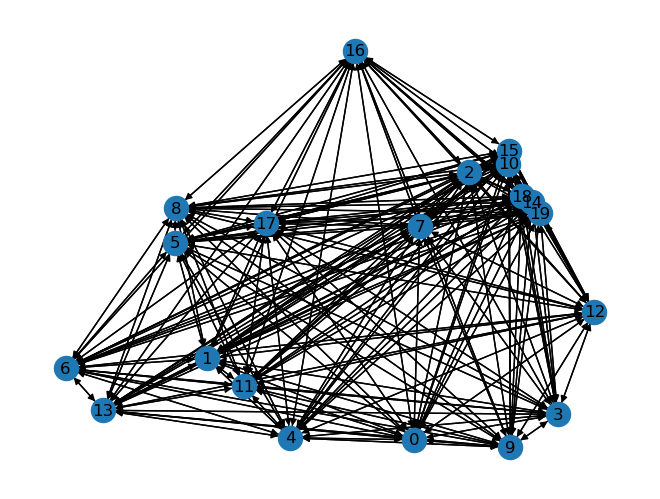

In [1]:
import random
import networkx as nx

# Hyperparameters:
EPS = 1e-2
CUT_THRESHOLD = 1.0 - EPS
random.seed(42)

# Create a random graph and visualize it:
n = 20
r = 0  # the root node
DG = nx.complete_graph(n, nx.DiGraph)

pos = {i: (random.random(), random.random()) for i in list(range(n))}
if n <= 30: nx.draw(DG, pos=pos, with_labels=True)

In [2]:
import math


def dist(x1, y1, x2, y2):
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)


def greedy_solution(source, nodes, space):
    if len(nodes) <= 1: return [], 0

    # Connect the source to the closest node:
    min_target = None
    min_arc_weight = float('inf')
    for v in nodes:
        if v == source: continue
        aux = space(source, v)
        if aux < min_arc_weight:
            min_target = v
            min_arc_weight = aux
    node_activation = {source: 0, min_target: min_arc_weight}
    sol_edges = [(source, min_target)]
    makespan = min_arc_weight

    # Init the degree map (-1 are not yet border nodes and -2 saturated nodes):
    degree = {v: -1 for v in nodes}
    degree[source] = -2
    degree[min_target] = 0

    border = [min_target]
    while len(sol_edges) < len(nodes) - 1:
        min_arc = (None, None)
        min_makespan = float('inf')
        for u in border:
            for v in nodes:
                if v == source or v == u: continue
                if degree[v] == -1:  # not yet added
                    aux = node_activation[u] + space(u, v)
                    if aux < min_makespan:
                        min_arc = (u, v)
                        min_makespan = aux
        u, v = min_arc
        if u is None: break
        sol_edges.append((u, v))
        node_activation[v] = min_makespan
        makespan = max(makespan, min_makespan)
        degree[u] += 1
        if degree[u] == 2:
            border.remove(u)
        degree[v] = 0
        border.append(v)
    return sol_edges, makespan


for i, j, d in DG.edges(data=True):
    (x1, y1) = pos[i]
    (x2, y2) = pos[j]
    d['w'] = dist(x1, y1, x2, y2)

In [3]:
import gurobipy as gp
from gurobipy import GRB

# Basic FTP edges model:
model = gp.Model()
# model.Params.OutputFlag = 0

# Edge usage variables:
x = model.addVars(DG.edges, name='x', vtype=GRB.BINARY)

# Depth variable:
d = model.addVar(vtype=GRB.CONTINUOUS)
model.update()

# Objective function:
model.setObjective(d, GRB.MINIMIZE)

# Each node (besides r) should have one incoming arc:
model.addConstrs(gp.quicksum(x[j, i] for j in DG.predecessors(i)) == 1 for i in DG.nodes if i != r)

# No incoming arc for the root:
model.addConstr(gp.quicksum(x[j, r] for j in DG.predecessors(r)) == 0)

# The root has out-degree one:
model.addConstr(gp.quicksum(x[r, j] for j in DG.successors(r)) == 1)

# Each node (besides r) should have at most two outgoing arcs:
model.addConstrs(gp.quicksum(x[i, j] for j in DG.successors(i)) <= 2 for i in DG.nodes if i != r)

# For each arc pair use at most one arc:
for i, j in DG.edges:
    model.addConstr(x[i, j] + x[j, i] <= 1)

model.update()

Set parameter Username
Set parameter LicenseID to value 2775738
Academic license - for non-commercial use only - expires 2027-02-05


In [4]:
# Add flow modeling:
f = model.addVars(DG.edges, DG.nodes, vtype=GRB.BINARY)
model.update()

# Flow usage constraints:
for i, j in DG.edges:
    for k in DG.nodes:
        model.addConstr(f[i, j, k] <= x[i, j])
        f[i, j, k].UB = int(k != r)  # no flow should target the root

# Flow conservation constraints:
for k in DG.nodes:
    if k == r: continue

    # The root should produce a unit of flow to be consumed by every other node:
    model.addConstr(gp.quicksum(f[r, i, k] for i in DG.successors(r)) == 1)  # production

    # Covered by the lazy constraints:
    # model.addConstr(gp.quicksum(f[i, k, k] for i in DG.predecessors(k)) == 1)  # consumption
    # model.addConstr(gp.quicksum(f[k, i, k] for i in DG.successors(k)) == 0)  # consume flow at node k

    continue  # adding these later dynamically
    # Each node should send at most one flow to every other node:
    for i in DG.nodes:
        if i == r or i == k: continue
        in_flow = gp.quicksum(f[j, i, k] for j in DG.predecessors(i))
        out_flow = gp.quicksum(f[i, j, k] for j in DG.successors(i))
        model.addConstr(out_flow == in_flow)
        # Too slow:
        # model.addConstr(in_flow <= 1)
        # model.addConstr(out_flow <= 1)

# Flow to depth connection constraints:
for k in DG.nodes:
    if k == r: continue
    model.addConstr(d >= gp.quicksum(f[i, j, k] * DG.edges[i, j]['w'] for i, j in DG.edges))

In [5]:
def subtour_cb(x_val, adder, target=None):
    # Build an undirected graph with selected edges:
    G = nx.Graph()
    for i, j in DG.edges:
        if x_val[i, j] > 0.0:
            G.add_edge(i, j, capacity=x_val[i, j])

    # Compute Gomory-Hu tree:
    added = 0
    if len(G.nodes) > 0:
        gh_tree = nx.gomory_hu_tree(G, capacity='capacity')

        # Check all cuts in the Gomory-Hu tree
        for u, v, w in gh_tree.edges(data='weight'):
            if w > CUT_THRESHOLD: continue

            # Remove the edge to get a cut
            gh_copy = gh_tree.copy()
            gh_copy.remove_edge(u, v)

            # Get the two components:
            components = list(nx.connected_components(gh_copy))

            # Check if the cut is violated:
            S = components[0] if r in components[0] else components[1]
            if target is not None and target in S: continue

            # Add lazy constraint: sum of edges leaving S >= 1
            cut_edges = []
            for i in S:
                for j in DG.successors(i):
                    if j not in S:
                        cut_edges.append(x[i, j])

            if len(cut_edges) > 0:
                adder(gp.quicksum(cut_edges) >= 1)
                added += 1
    return added

In [6]:
def flow_cb(f_val, adder):
    added = 0
    for k in DG.nodes:
        if k == r: continue
        x_val = {(i, j): f_e_k for (i, j, l), f_e_k in f_val.items() if l == k}
        added += subtour_cb(x_val, adder, target=k)

        # Each node should send at most one flow to every other node:
        for i in DG.nodes:
            if i == r or i == k: continue
            in_flow = sum(x_val[j, i] for j in DG.predecessors(i))
            out_flow = sum(x_val[i, j] for j in DG.successors(i))
            if abs(in_flow - out_flow) > EPS:
                in_flow = gp.quicksum(f[j, i, k] for j in DG.predecessors(i))
                out_flow = gp.quicksum(f[i, j, k] for j in DG.successors(i))
                adder(in_flow == out_flow)
                added += 1
    return added

In [7]:
def cb(m, where):
    if where != GRB.Callback.MIPSOL and where != GRB.Callback.MIPNODE: return

    # Chose the function to get variable values depending on when the callback is called:
    if where == GRB.Callback.MIPNODE:
        if m.cbGet(GRB.Callback.MIPNODE_STATUS) != GRB.OPTIMAL: return
        getval = lambda var: abs(m.cbGetNodeRel(var))
    else:
        getval = lambda var: abs(m.cbGetSolution(var))

    adder = m.cbCut if where == GRB.Callback.MIPNODE else m.cbLazy
    # Get current solution:
    x_val = {e: getval(x_e) for e, x_e in x.items()}
    f_val = {e_k: getval(f_e_k) for e_k, f_e_k in f.items()}

    added = subtour_cb(x_val, adder)
    if added: print(f'\t- Added {added} sub-tour constrains;')
    added = flow_cb(f_val, adder)
    if added: print(f'\t- Added {added} flow constrains;')

In [8]:
# Model solving:
model.update()

# Warm start:
greedy_edges, greedy_makespan = greedy_solution(r, DG.nodes, lambda u, v: DG.edges[u, v]['w'])

# Set x variables:
for i, j in DG.edges:
    if (i, j) in greedy_edges:
        x[i, j].Start = 1
    else:
        x[i, j].Start = 0

# Set d variable:
d.Start = greedy_makespan

# Set f variables:
tree = nx.DiGraph(greedy_edges)
for k in DG.nodes:
    if k == r: continue
    path = nx.shortest_path(tree, r, k)
    path_edges = set(zip(path, path[1:]))
    for i, j in DG.edges:
        if (i, j) in path_edges:
            f[i, j, k].Start = 1
        else:
            f[i, j, k].Start = 0

model.Params.LazyConstraints = 1
model.optimize(cb)
# model.optimize()

Set parameter LazyConstraints to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Pop!_OS 22.04 LTS")

CPU model: AMD Ryzen 7 8845HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
LazyConstraints  1

Optimize a model with 8058 rows, 7981 columns and 24320 nonzeros
Model fingerprint: 0xca40307e
Variable types: 1 continuous, 7980 integer (7980 binary)
Coefficient statistics:
  Matrix range     [2e-02, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Loaded user MIP start with objective 1.33569

Presolve removed 1331 rows and 1121 columns
Presolve time: 0.07s
Presolved: 6727 rows, 6860 columns, 20919 nonzeros
Variable types: 1 continuous, 6859 integer (6859 binary)

Root relaxation: objective 1.710086e-01, 108 iterations, 0.00 seconds (0.01 work units)
	- Added 3 sub-tour constrains;
	- Adde

Makespan = 1.176


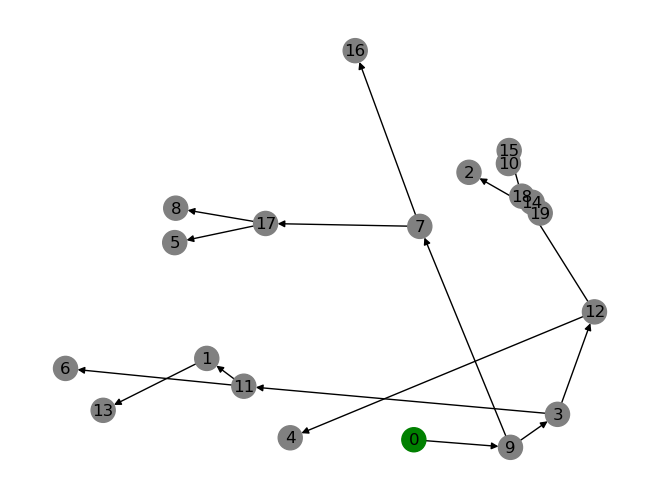

In [9]:
# Visualize the solution:
sol_x = model.getAttr('x', x)
sol_edges = [e for e in DG.edges if sol_x[e] > 1.0 - EPS]
node_colors = ['green' if i == r else 'gray' for i in DG.nodes]
nx.draw(DG.edge_subgraph(sol_edges), pos=pos, with_labels=True, node_color=node_colors)

print(f'Makespan = {model.objVal:.3f}')